In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import(accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)

In [ ]:
wine = load_wine()
X,y = wine.data, wine.target
print("Feature Name:")
print(wine.feature_names)
print("\n")
print("Target Name:")
print(wine.target_names)
print("\n")

Feature Name:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


Target Name:
['class_0' 'class_1' 'class_2']




In [ ]:
df = pd.DataFrame(X, columns = wine.feature_names)
df["Target"]=y


In [ ]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=5, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(100,10), activation="relu", solver="adam")
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of the Model is: ", accuracy,"%")

Accuracy of the Model is:  0.9722222222222222 %


In [ ]:
cm=confusion_matrix(y_test, y_pred)
print("Confusion Matrix for the above model: ")
print(cm)

Confusion Matrix for the above model: 
[[12  0  0]
 [ 0 13  1]
 [ 0  0 10]]


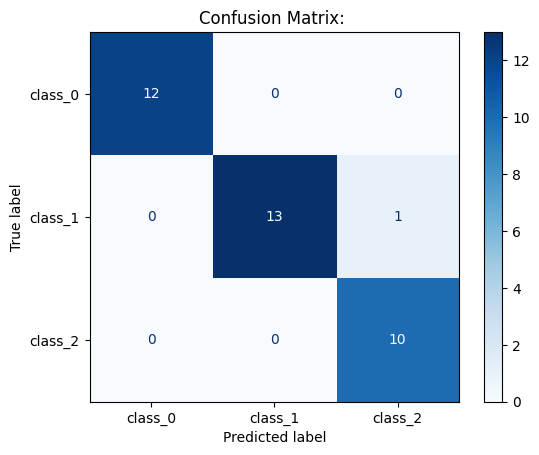

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=wine.target_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: ")
plt.show()

In [ ]:
print(classification_report(y_test, y_pred, target_names = wine.target_names))


              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      0.93      0.96        14
     class_2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



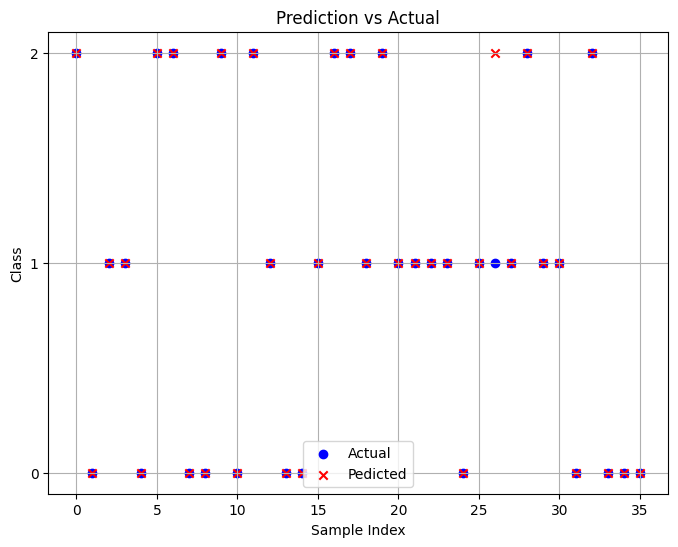

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(range(len(y_test)), y_test, color="blue", label="Actual", marker="o")
plt.scatter(range(len(y_pred)), y_pred, color="red", label="Pedicted", marker="x")

plt.xlabel("Sample Index")
plt.ylabel("Class")
plt.title("Prediction vs Actual")
plt.yticks([0,1,2])
plt.legend()
plt.grid(True)
plt.show()